In [23]:
import torch
from PIL import Image
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
from IPython.display import display
import torch
import torch.nn.functional as F

In [8]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:
image_id = '000021'
image_path = f'/home/ubuntu/RecycleCloth/Datasets/DeepFashion2/deepfashion2_original_images/train/image/{image_id}.jpg'
annos_image_path = f'/home/ubuntu/RecycleCloth/Datasets/DeepFashion2/deepfashion2_original_images/train/annos/{image_id}.json'

df = pd.read_json(annos_image_path)

bounding_box_1 = df['item1']['bounding_box']
segmentation_1 = df['item1']['segmentation']
landmarks_1 = df['item1']['landmarks']
category_name_1 = df['item1']['category_name']

bounding_box_2 = df['item2']['bounding_box']
segmentation_2 = df['item2']['segmentation']
landmarks_2 = df['item2']['landmarks']
category_name_2 = df['item2']['category_name']

print(f'Bounding Box: {bounding_box_1}')
print(f'Segmentation: {segmentation_1}')
print(f'Landmarks: {landmarks_1}')
print(f'Category Name: {category_name_1}')

print(f'Bounding Box: {bounding_box_2}')
print(f'Segmentation: {segmentation_2}')
print(f'Landmarks: {landmarks_2}')
print(f'Category Name: {category_name_2}')

Bounding Box: [128, 196, 289, 333]
Segmentation: [[237, 200, 222, 214, 203, 216, 185, 211, 174, 198, 138, 214, 133, 246, 128, 272, 150, 278, 151, 264, 150, 251, 150, 266, 162, 296, 164, 323, 205, 325, 244, 322, 247, 289, 247, 260, 250, 251, 248, 264, 248, 278, 285, 274, 285, 250, 281, 226, 237, 200], [138, 214, 133, 246, 128, 272, 150, 278, 151, 264, 150, 251, 138, 214], [250, 251, 248, 264, 248, 278, 285, 274, 285, 250, 281, 226, 250, 251]]
Landmarks: [203, 199, 1, 174, 198, 1, 185, 211, 1, 203, 216, 1, 222, 214, 1, 237, 200, 1, 138, 214, 2, 133, 246, 1, 128, 272, 1, 150, 278, 1, 151, 264, 2, 150, 251, 2, 150, 266, 2, 162, 296, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 247, 289, 1, 247, 260, 1, 250, 251, 2, 248, 264, 1, 248, 278, 1, 285, 274, 2, 285, 250, 2, 281, 226, 2]
Category Name: short sleeve top
Bounding Box: [113, 314, 287, 504]
Segmentation: [[164, 322, 205, 325, 246, 319, 281, 383, 279, 470, 199, 500, 122, 471, 122, 391, 164, 322]]
Landmarks: [164, 322, 2, 205, 325, 2, 246, 319, 1, 122,

In [9]:
from transformers import AutoProcessor, CLIPSegForImageSegmentation, CLIPSegConfig, CLIPSegModel

processor = AutoProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
model.eval()
model.to(DEVICE)

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextModel(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, ou

In [24]:
image_id = '000041'
image_path = f'/home/ubuntu/RecycleCloth/Datasets/DeepFashion2/deepfashion2_original_images/train/image/{image_id}.jpg'

image = Image.open(image_path).convert("RGB")
texts = ["cloth"]   # you can pass multiple prompts


inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt"
)

inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

# logits shape: (batch_size, height, width)
logits = outputs.logits

# Convert logits to probabilities
probs = torch.sigmoid(logits)

# Threshold to get binary mask
mask = (probs > 0.5).float()

# Take first prompt
mask = mask[0].cpu().numpy()


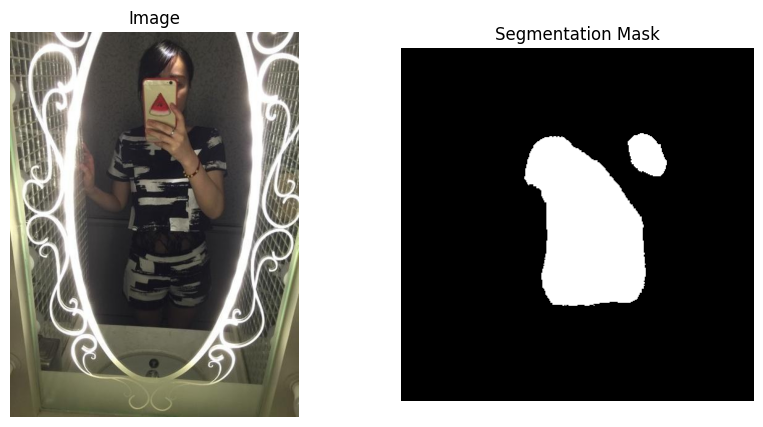

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentation Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()
